# 삼각김밥팀 대만 기업 파산 예측 데이터톤 코드
여러 모델을, 많이 수정했기 때문에 모델별 가장 기본이 되는 코드를 작성했습니다  
각 모델들은 추후에 튜닝을 더 거쳤습니다  
각 모델들은 더 튜닝을 거쳐 성능을 향상시키기 위한 baseline으로 사용되었습니다

## 데이터 로드, EDA

In [28]:
import pandas as pd
import numpy as np

train = pd.read_parquet('/content/train.parquet')
test = pd.read_parquet('/content/test.parquet')

In [29]:
X = train.drop(columns=['Bankrupt?'])
y = train['Bankrupt?']

In [30]:
print(X.shape, y.shape)

(4773, 96) (4773,)


In [31]:
train.describe()

,ID,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,4773.000000,4773.000000,4773.000000,4.773000e+03,4773.000000,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,...,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4.773000e+03,4773.0,4.773000e+03
mean,2386.000000,0.032265,0.505116,5.585866e-01,0.553486,6.081508e-01,6.081384e-01,9.986685e-01,7.971204e-01,8.090041e-01,...,8.078634e-01,1.891138e+07,6.238792e-01,6.081491e-01,8.404248e-01,2.802793e-01,2.750943e-02,5.654425e-01,1.0,4.864183e-02
std,1377.990747,0.176721,0.060265,6.428778e-02,0.061079,1.628336e-02,1.627036e-02,1.553431e-02,1.512256e-02,1.603066e-02,...,3.945613e-02,3.785395e+08,1.300337e-02,1.628335e-02,1.497497e-02,1.576839e-02,1.225516e-02,1.223511e-02,0.0,5.400546e-02
min,0.000000,0.000000,0.024277,3.595562e-16,0.033514,-3.619544e-16,-7.464126e-16,9.098560e-16,-1.245180e-16,-1.057739e-16,...,3.494474e-16,4.383144e-16,-5.368305e-16,-8.688090e-16,-6.822844e-16,3.947920e-16,-1.517283e-16,-7.481682e-16,1.0,-3.893325e-16
25%,1193.000000,0.000000,0.476283,5.355975e-01,0.527384,6.006428e-01,6.006284e-01,9.989694e-01,7.973863e-01,8.093124e-01,...,7.969034e-01,8.836298e-04,6.236395e-01,6.006387e-01,8.401215e-01,2.768898e-01,2.679116e-02,5.651584e-01,1.0,2.462871e-02
50%,2386.000000,0.000000,0.502901,5.600741e-01,0.552385,6.061056e-01,6.061200e-01,9.990235e-01,7.974655e-01,8.093761e-01,...,8.107212e-01,2.063484e-03,6.238848e-01,6.061021e-01,8.411882e-01,2.786880e-01,2.680738e-02,5.652477e-01,1.0,3.434130e-02
75%,3579.000000,0.000000,0.535855,5.891845e-01,0.584293,6.140691e-01,6.140979e-01,9.990967e-01,7.975815e-01,8.094721e-01,...,8.262486e-01,5.255960e-03,6.241758e-01,6.140690e-01,8.423445e-01,2.813802e-01,2.690519e-02,5.657034e-01,1.0,5.376724e-02
max,4772.000000,1.000000,0.971530,1.000000e+00,1.000000,6.651508e-01,6.660229e-01,1.000000e+00,1.000000e+00,1.000000e+00,...,9.813151e-01,9.820000e+09,1.000000e+00,6.651492e-01,1.000000e+00,1.000000e+00,5.406717e-01,1.000000e+00,1.0,1.000000e+00


In [32]:
value_counts = train['Net Income Flag'].value_counts()

print(value_counts)

Net Income Flag
1    4773
Name: count, dtype: int64


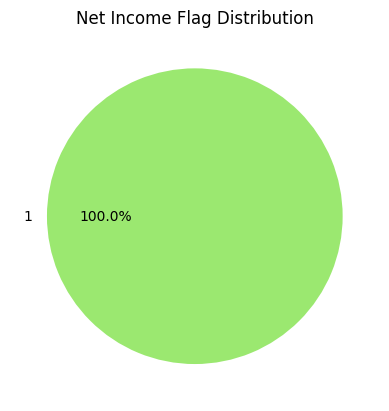

In [33]:
import matplotlib.pyplot as plt

labels = value_counts.index.astype(str)
sizes = value_counts.values

# 연두색 계열 색상
colors = ['#9BE870', '#C7F9A6']  # 연두 계열

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)

plt.title('Net Income Flag Distribution')
plt.show()

In [34]:
X.drop(columns=['Net Income Flag'], inplace=True)

In [35]:
# 각 컬럼의 최대값 - 최소값
range_series = train.max() - train.min()

# 범위 내림차순 정렬
range_series = range_series.sort_values(ascending=False)

print(range_series)

top_n = 10
top_range_cols = range_series.head(top_n)

print(top_range_cols)

Current Asset Turnover Rate                1.000000e+10
Quick Asset Turnover Rate                  1.000000e+10
Cash Turnover Rate                         1.000000e+10
Fixed Assets Turnover Frequency            9.990000e+09
Total Asset Growth Rate                    9.990000e+09
                                               ...     
Cash Flow to Equity                        5.692307e-01
Degree of Financial Leverage (DFL)         5.406717e-01
Interest Expense Ratio                     4.378022e-01
Realized Sales Gross Profit Growth Rate    8.345484e-02
Net Income Flag                            0.000000e+00
Length: 97, dtype: float64
Current Asset Turnover Rate              1.000000e+10
Quick Asset Turnover Rate                1.000000e+10
Cash Turnover Rate                       1.000000e+10
Fixed Assets Turnover Frequency          9.990000e+09
Total Asset Growth Rate                  9.990000e+09
Inventory Turnover Rate (times)          9.990000e+09
Operating Expense Rate           

In [36]:
corr = X.corr(numeric_only=True)

Current Liabilities/Liability        Current Liability to Liability          1.000000
Current Liabilities/Equity           Current Liability to Equity             1.000000
Debt ratio %                         Net worth/Assets                        1.000000
Operating Gross Margin               Gross Profit to Sales                   1.000000
Net Value Per Share (A)              Net Value Per Share (C)                 0.999843
Operating Gross Margin               Realized Sales Gross Margin             0.999576
Realized Sales Gross Margin          Gross Profit to Sales                   0.999576
Pre-tax net Interest Rate            Continuous interest rate (after tax)    0.999192
Operating Profit Per Share (Yuan ¥)  Operating profit/Paid-in capital        0.999172
Net Value Per Share (B)              Net Value Per Share (A)                 0.999122
dtype: float64


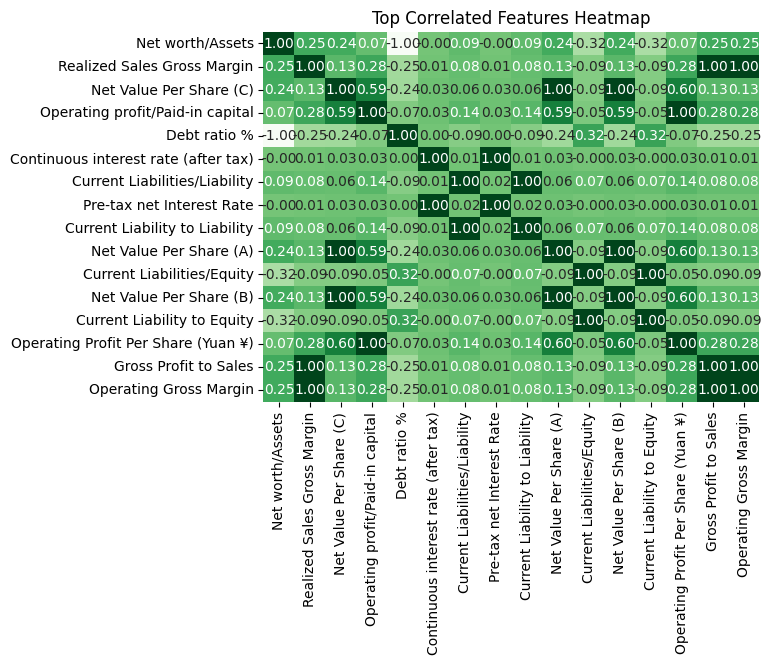

In [37]:
# 상관행렬을 1차원으로 펼치기
corr_unstack = corr.unstack()

# 자기 자신 제거
corr_unstack = corr_unstack[corr_unstack.index.get_level_values(0) != corr_unstack.index.get_level_values(1)]

# 중복 제거 (A-B, B-A 제거)
corr_unstack = corr_unstack.drop_duplicates()

# 절대값 기준으로 정렬
top_corr = corr_unstack.abs().sort_values(ascending=False)

# 상위 10개
top_10 = top_corr.head(10)

print(top_10)

# 컬럼 이름 추출
cols = list(set([i[0] for i in top_10.index] + [i[1] for i in top_10.index]))

# 부분 상관행렬
corr_subset = train[cols].corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(corr_subset, annot=True, fmt=".2f", cmap='Greens',cbar=False)
plt.title('Top Correlated Features Heatmap')
plt.show()

In [38]:
import numpy as np

# 상관행렬
corr = X.corr(numeric_only=True)

# 상삼각행렬 (중복 제거)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# 절댓값 기준 0.9 이상
threshold = 0.9
to_drop = [col for col in upper.columns if any(upper[col].abs() > threshold)]

print("제거할 컬럼:")
print(to_drop)

# 제거 전
before_cols = X.shape[1]

# 제거
X_reduced = X.drop(columns=to_drop)

# 제거 후
after_cols = X_reduced.shape[1]

print(f"제거 전: {before_cols}")
print(f"제거 후: {after_cols}")
print(f"제거된 개수: {before_cols - after_cols}")

제거할 컬럼:
['ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Realized Sales Gross Margin', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Continuous interest rate (after tax)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Per Share Net profit before tax (Yuan ¥)', 'Regular Net Profit Growth Rate', 'Net worth/Assets', 'Operating profit/Paid-in capital', 'Net profit before tax/Paid-in capital', 'Cash Flow to Sales', 'Current Liability to Liability', 'Current Liability to Equity', 'Net Income to Total Assets', 'Gross Profit to Sales', 'Liability to Equity']
제거 전: 95
제거 후: 76
제거된 개수: 19


In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

threshold = 10

def calculate_vif(df):
    vif = pd.DataFrame()
    vif["feature"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif

X_vif = X_reduced.copy()

# NaN / inf 제거
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

while True:
    if X_vif.shape[1] <= 1:
        break

    vif = calculate_vif(X_vif)
    max_vif = vif["VIF"].max()

    if max_vif < threshold:
        break

    drop_col = vif.sort_values("VIF", ascending=False)["feature"].iloc[0]
    print(f"제거: {drop_col} (VIF={max_vif:.2f})")

    X_vif = X_vif.drop(columns=[drop_col])

before_cols_vif = X_reduced.shape[1]
after_cols_vif = X_vif.shape[1]

print(f"제거 전: {before_cols_vif}")
print(f"제거 후: {after_cols_vif}")
print(f"제거된 개수: {before_cols_vif - after_cols_vif}")

제거: Current Liabilities/Equity (VIF=72344.32)
제거: Inventory and accounts receivable/Net value (VIF=16958.85)
제거: After-tax Net Profit Growth Rate (VIF=5814.46)
제거: No-credit Interval (VIF=2359.04)
제거: Cash Flow to Equity (VIF=7205.34)
제거: Cash flow rate (VIF=5062.54)
제거: Borrowing dependency (VIF=4825.12)
제거: Cash Flow Per Share (VIF=1147.79)
제거: Cash Flow to Liability (VIF=606.30)
제거: Current Liability to Assets (VIF=940.18)
제거: Operating Profit Growth Rate (VIF=4795.78)
제거: Continuous Net Profit Growth Rate (VIF=356.57)
제거: Realized Sales Gross Profit Growth Rate (VIF=94.27)
제거: Current Assets/Total Assets (VIF=46.55)
제거: Working Capital/Equity (VIF=11.27)
제거: Operating Profit Rate (VIF=8344.06)
제거: Working capitcal Turnover Rate (VIF=8123.38)
제거: Operating Gross Margin (VIF=2367.81)
제거: Interest Expense Ratio (VIF=5308.22)
제거: Interest Coverage Ratio (Interest expense to EBIT) (VIF=1922.50)
제거: Cash Reinvestment % (VIF=892.23)
제거: Non-industry income and expenditure/revenue (VIF=616

## 선형 모델

In [40]:
# 전처리 스케일링 -> PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (설명력 95% 유지)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

In [41]:
before_cols_pca = X.shape[1]
after_cols_pca = X_pca.shape[1]

print(f"원래 변수 개수: {before_cols_pca}")
print(f"PCA 후 변수 개수: {after_cols_pca}")
print(f"줄어든 개수: {before_cols_pca - after_cols_pca}")

원래 변수 개수: 95
PCA 후 변수 개수: 52
줄어든 개수: 43


In [42]:
print("총 설명 분산 비율:", sum(pca.explained_variance_ratio_))

총 설명 분산 비율: 0.9501650160619188


In [43]:
#선형모델
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, fbeta_score

In [46]:
# F2 score (recall 더 중요)
f2_scorer = make_scorer(fbeta_score, beta=2)

param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_)

y_proba = grid.predict_proba(X_test)[:, 1]

import numpy as np
from sklearn.metrics import fbeta_score

thresholds = np.arange(0.1, 0.9, 0.01)
f2_scores = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    score = fbeta_score(y_test, y_pred, beta=2)
    f2_scores.append(score)

# 최적 threshold
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print("최적 threshold:", best_threshold)
print("최고 F2 score:", f2_scores[best_idx])

최적 파라미터: {'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
최적 threshold: 0.6099999999999998
최고 F2 score: 0.5


In [47]:
from sklearn.metrics import classification_report

# 최적 threshold 적용
y_pred_final = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.90      0.94       924
           1       0.21      0.77      0.33        31

    accuracy                           0.90       955
   macro avg       0.60      0.84      0.64       955
weighted avg       0.97      0.90      0.92       955



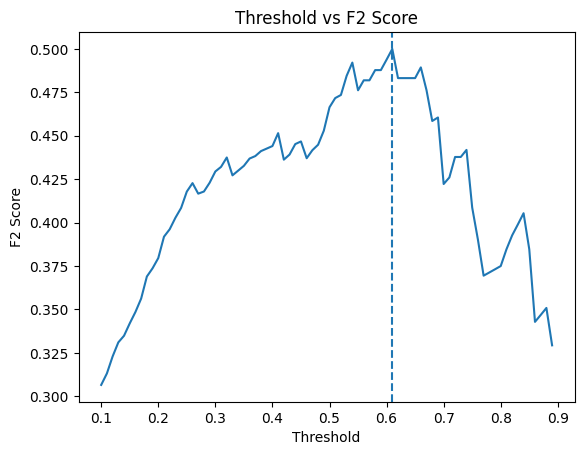

In [48]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, f2_scores)
plt.axvline(best_threshold, linestyle='--')
plt.title('Threshold vs F2 Score')
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.show()

In [49]:
from sklearn.metrics import fbeta_score

# train 성능
y_train_pred = grid.predict(X_train)
train_f2 = fbeta_score(y_train, y_train_pred, beta=2)

# test 성능
y_test_pred = grid.predict(X_test)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)

print("Train F2:", train_f2)
print("Test F2:", test_f2)

Train F2: 0.49575070821529743
Test F2: 0.4664179104477612


In [50]:
# 최종 모델 학습 (전체 train)
best_model.fit(X_train, y_train)

# test 평가
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

final_f2 = fbeta_score(y_test, y_pred_test, beta=2)
print("최종 Test F2 score:", final_f2)

최종 Test F2 score: 0.5


## CatBoost

In [74]:
#데이터 전처리
import pandas as pd
import numpy as np

# 상관계수 계산
corr_matrix = X.corr().abs()

# 상삼각 행렬만 사용
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 상관계수 0.9 이상 컬럼 찾기
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.9)]

print("상관계수로 제거할 컬럼:", to_drop_corr)

# 제거
X_reduced = X.drop(columns=to_drop_corr)

# NaN / inf 제거
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

removed_vif_cols = []

while True:
    if X_vif.shape[1] <= 1:
        break

    vif = calculate_vif(X_vif)
    max_vif = vif["VIF"].max()

    if max_vif < threshold:
        break

    drop_col = vif.sort_values("VIF", ascending=False)["feature"].iloc[0]
    removed_vif_cols.append(drop_col)

    print(f"VIF 제거: {drop_col} (VIF={max_vif:.2f})")

    X_vif = X_vif.drop(columns=[drop_col])

상관계수로 제거할 컬럼: ['ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Realized Sales Gross Margin', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Continuous interest rate (after tax)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Per Share Net profit before tax (Yuan ¥)', 'Regular Net Profit Growth Rate', 'Net worth/Assets', 'Operating profit/Paid-in capital', 'Net profit before tax/Paid-in capital', 'Cash Flow to Sales', 'Current Liability to Liability', 'Current Liability to Equity', 'Net Income to Total Assets', 'Gross Profit to Sales', 'Liability to Equity']


In [75]:
#데이터 분할
from sklearn.model_selection import train_test_split

X = X_vif.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [76]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.1 MB/s eta 0:00:00


In [77]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, fbeta_score

# F2 score (recall 중요)
f2_scorer = make_scorer(fbeta_score, beta=2)

model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

param_dist = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.1],
    'iterations': [100, 300, 500],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 64, 128]
}

In [78]:
#시간상의 이유로 랜덤 서치
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,
    scoring=f2_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=CatBoostClassifier(random_state=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'border_count': [32, 64, 128],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [100, 300, 500],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.1]},
                   random_state=42,
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
                   verbose=1)

실제 데이터톤에서는 랜덤서치와 그리드서치 모두 사용해봤습니다  
그 결과 그리드 서치가 더 좋은 성능을 보였습니다

In [79]:
print("최적 파라미터:", random_search.best_params_)
print("최고 CV F2 score:", random_search.best_score_)

최적 파라미터: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 6, 'border_count': 32}
최고 CV F2 score: 0.23905263586551745


In [80]:
#최적의 임계값
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score
import numpy as np

best_model = random_search.best_estimator_

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

thresholds = np.arange(0.1, 0.9, 0.01)
threshold_scores = np.zeros(len(thresholds))

for train_idx, val_idx in skf.split(X_train, y_train):

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best_model.fit(X_tr, y_tr)

    y_proba = best_model.predict_proba(X_val)[:, 1]

    for i, t in enumerate(thresholds):
        y_pred = (y_proba >= t).astype(int)

        score = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
        threshold_scores[i] += score

# 평균 score
threshold_scores /= skf.get_n_splits()

# 최적 threshold
best_idx = np.argmax(threshold_scores)
best_threshold = thresholds[best_idx]

print("CV 기반 최적 threshold:", best_threshold)
print("CV 기반 최고 F2 score:", threshold_scores[best_idx])

CV 기반 최적 threshold: 0.11
CV 기반 최고 F2 score: 0.3621251383538152


In [81]:
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= best_threshold).astype(int)

from sklearn.metrics import fbeta_score

final_f2 = fbeta_score(y_test, y_pred_test, beta=2)
print("최종 Test F2 score:", final_f2)

최종 Test F2 score: 0.5298013245033113


In [82]:
#과적합 확인
print("CV F2 score:", random_search.best_score_)

from sklearn.metrics import fbeta_score

# Train 성능
y_pred_train = best_model.predict(X_train)
train_f2 = fbeta_score(y_train, y_pred_train, beta=2)

# Test 성능
y_pred_test = best_model.predict(X_test)
test_f2 = fbeta_score(y_test, y_pred_test, beta=2)

print("Train F2:", train_f2)
print("Test F2:", test_f2)

CV F2 score: 0.23905263586551745
Train F2: 0.8735440931780366
Test F2: 0.35714285714285715


## LightGBM

In [52]:
smote = SMOTE(random_state=42)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_probs_lgb = np.zeros(len(df_test_final))
oof_lgb = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kfold.split(X, y)):
    X_tr, X_vl = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_vl = y.iloc[train_idx], y.iloc[val_idx]

    X_tr_res, y_tr_res = smote.fit_resample(X_tr, y_tr)

    model_lgb = lgb.LGBMClassifier(**best_params)
    model_lgb.fit(X_tr_res, y_tr_res)

    oof_lgb[val_idx] = model_lgb.predict_proba(X_vl)[:, 1]
    test_probs_lgb += model_lgb.predict_proba(df_test_final)[:, 1] / 5

    f2 = fbeta_score(y_vl, (oof_lgb[val_idx] >= 0.09).astype(int), beta=2)
    print(f'Fold {fold+1}  F2: {f2:.4f}')

# OOF 기준 최적 임계값 재탐색
print('\n=== 임계값 탐색 ===')
best_f2, best_t = 0, 0.09
for t in np.arange(0.01, 0.50, 0.01):
    pred = (oof_lgb >= t).astype(int)
    f2 = fbeta_score(y, pred, beta=2)
    if f2 > best_f2:
        best_f2, best_t = f2, t

print(f'최적 임계값: {best_t:.2f}  |  OOF F2: {best_f2:.4f}')

y_test_pred = (test_probs_lgb >= best_t).astype(int)
print(f'\n부도 예측 수: {y_test_pred.sum()}개')
print(f'예측 부도율: {y_test_pred.mean():.2%}')

submission = pd.DataFrame({
    'ID': test_ids.values,
    'Bankrupt?': y_test_pred
})

assert len(submission) == 2046
assert submission['ID'].duplicated().sum() == 0

submission.to_csv('result.csv', index=False, encoding='utf-8')
print('\nresult.csv 저장 완료 ✅')


result.csv 저장 완료 ✅


Fold 1 F2: 0.5729 Fold 2 F2: 0.5476 Fold 3 F2: 0.5682 Fold 4 F2: 0.5583 Fold 5 F2: 0.5419  

=== 임계값 탐색 === 최적 임계값: 0.14 | OOF F2: 0.5734  

부도 예측 수: 175개 예측 부도율: 8.55%  

result.csv 저장 완료 ✅  

## RandomForest

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import fbeta_score, classification_report, confusion_matrix


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [55]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 25.9 MB/s eta 0:00:00


In [56]:
from imblearn.over_sampling import SMOTE
import optuna

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [61]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score
from imblearn.over_sampling import SMOTE
import numpy as np

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f2_scores = []

    thresholds = np.arange(0.1, 0.5, 0.05)

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # ✅ fold 내부에서 SMOTE
        smote = SMOTE(random_state=42)
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

        model = RandomForestClassifier(
            **params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

        model.fit(X_tr_sm, y_tr_sm)

        y_prob = model.predict_proba(X_val)[:, 1]

        best_f2_fold = 0

        for th in thresholds:
            y_pred = (y_prob >= th).astype(int)
            f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)

            if f2 > best_f2_fold:
                best_f2_fold = f2

        f2_scores.append(best_f2_fold)

    return np.mean(f2_scores)

In [62]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best F2:", study.best_value)

[I 2026-03-30 15:51:36,995] A new study created in memory with name: no-name-4ba464f0-f718-4e09-b4f5-1034d1e3caa5
[I 2026-03-30 15:52:58,469] Trial 0 finished with value: 0.5270685381203164 and parameters: {'n_estimators': 464, 'max_depth': 5, 'min_samples_split': 19, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5270685381203164.
[I 2026-03-30 15:53:12,053] Trial 1 finished with value: 0.5404212505227811 and parameters: {'n_estimators': 132, 'max_depth': 6, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 1 with value: 0.5404212505227811.
[I 2026-03-30 15:53:52,409] Trial 2 finished with value: 0.5106326627589464 and parameters: {'n_estimators': 315, 'max_depth': 4, 'min_samples_split': 19, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.5404212505227811.
[I 2026-03-30 15:54:21,348] Trial 3 finished with value: 0.5564386245213545 and parameters: {'n_estimators': 239, 'max_depth': 9, 'm

Best Params: {'n_estimators': 290, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2'}
Best F2: 0.5688814558141493


In [69]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# 1. SMOTE 전체 train에 적용
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 2. 최적 파라미터로 모델 생성
best_model = RandomForestClassifier(
    **study.best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 3. 최종 학습
best_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       max_features='log2', min_samples_leaf=4,
                       min_samples_split=9, n_estimators=290, n_jobs=-1,
                       random_state=42)

In [70]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score, precision_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

thresholds = np.linspace(0.05, 0.4, 100)

threshold_scores = np.zeros(len(thresholds))
threshold_counts = np.zeros(len(thresholds))  # 🔥 핵심

for train_idx, val_idx in skf.split(X_train, y_train):


    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # SMOTE (fold 내부 적용)
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

    # 모델 재학습
    best_model.fit(X_tr_sm, y_tr_sm)

    # 확률 예측
    y_prob = best_model.predict_proba(X_val)[:, 1]

    for i, th in enumerate(thresholds):

        y_pred = (y_prob >= th).astype(int)

        f2 = fbeta_score(y_val, y_pred, beta=2, zero_division=0)
        precision = precision_score(y_val, y_pred, zero_division=0)

        # 🔥 precision 조건
        if precision >= 0.30:
            threshold_scores[i] += f2
            threshold_counts[i] += 1

# 평균 계산 (조건 만족한 것만)
threshold_avg = np.divide(
    threshold_scores,
    threshold_counts,
    out=np.zeros_like(threshold_scores),
    where=threshold_counts != 0
)

# 최적 threshold 선택
best_idx = np.argmax(threshold_avg)
best_th = thresholds[best_idx]
best_f2 = threshold_avg[best_idx]

print("✅ Best Threshold:", best_th)
print("✅ Best CV F2:", best_f2)

✅ Best Threshold: 0.4
✅ Best CV F2: 0.650887573964497


In [71]:
from sklearn.metrics import fbeta_score, precision_score, recall_score

y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= best_th).astype(int)

print("Test F2:", fbeta_score(y_test, y_pred_test, beta=2))
print("Test Precision:", precision_score(y_test, y_pred_test))
print("Test Recall:", recall_score(y_test, y_pred_test))

Test F2: 0.5472636815920398
Test Precision: 0.2857142857142857
Test Recall: 0.7096774193548387


In [72]:
# ===============================
# 1. validation 기준 최종 예측
# ===============================
y_pred_val = (y_prob >= best_th).astype(int)

# ===============================
# 2. 성능 출력
# ===============================
from sklearn.metrics import classification_report, confusion_matrix

print("\n📊 [Validation Classification Report]")
print(classification_report(y_val, y_pred_val))

# ===============================
# 3. Confusion Matrix 출력
# ===============================
cm = confusion_matrix(y_val, y_pred_val)

print("\n📌 Confusion Matrix")
print(cm)


📊 [Validation Classification Report]
              precision    recall  f1-score   support

           0       0.99      0.92      0.96       739
           1       0.25      0.79      0.38        24

    accuracy                           0.92       763
   macro avg       0.62      0.86      0.67       763
weighted avg       0.97      0.92      0.94       763


📌 Confusion Matrix
[[683  56]
 [  5  19]]


위 코드는 최종모델의 기본이 되는 코드입니다. 실제 데이터톤에서는 위 코드를 발전시켜(파라미터튜닝, 과적합 처리) 모델을 만들었습니다  
따라서 위 모델보다 성능이 좋게 나왔습니다 (precision 0.4정도)